# Chapter 22: The Causal Forecaster
Synthetic treated and control series share a trend. We compute difference in
differences, a pre-period regression counterfactual, and placebo estimates.
The regression is not the Bayesian CausalImpact package.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
rng=begin(22); t=np.arange(120); intervention=80
control=100+.25*t+3*np.sin(t/6)+rng.normal(0,1,120)
treated=12+1.0*control+rng.normal(0,1.5,120)+np.where(t>=80,8,0)

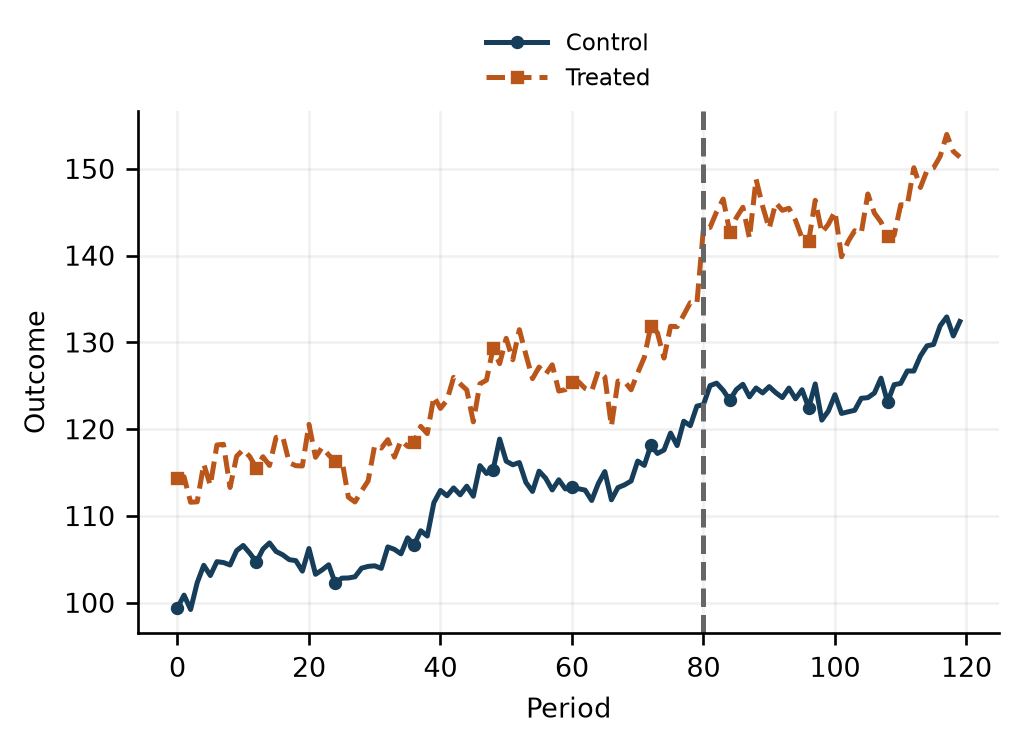

In [2]:
plt.figure(); plt.plot(control,label='Control'); plt.plot(treated,label='Treated'); plt.axvline(80,ls='--',color='.4'); plt.xlabel('Period'); plt.ylabel('Outcome'); plt.legend()
save(22,1,'An intervention against a common trend','Synthetic treated and control outcomes with an eight-unit treatment effect starting at period 80.','## Section 3: When Forecasting and Causation Meet')

## Fit only the pre-intervention relationship
The control's post-period values must be unaffected by treatment. Otherwise the
counterfactual inherits post-treatment bias even if its fit looks convincing.

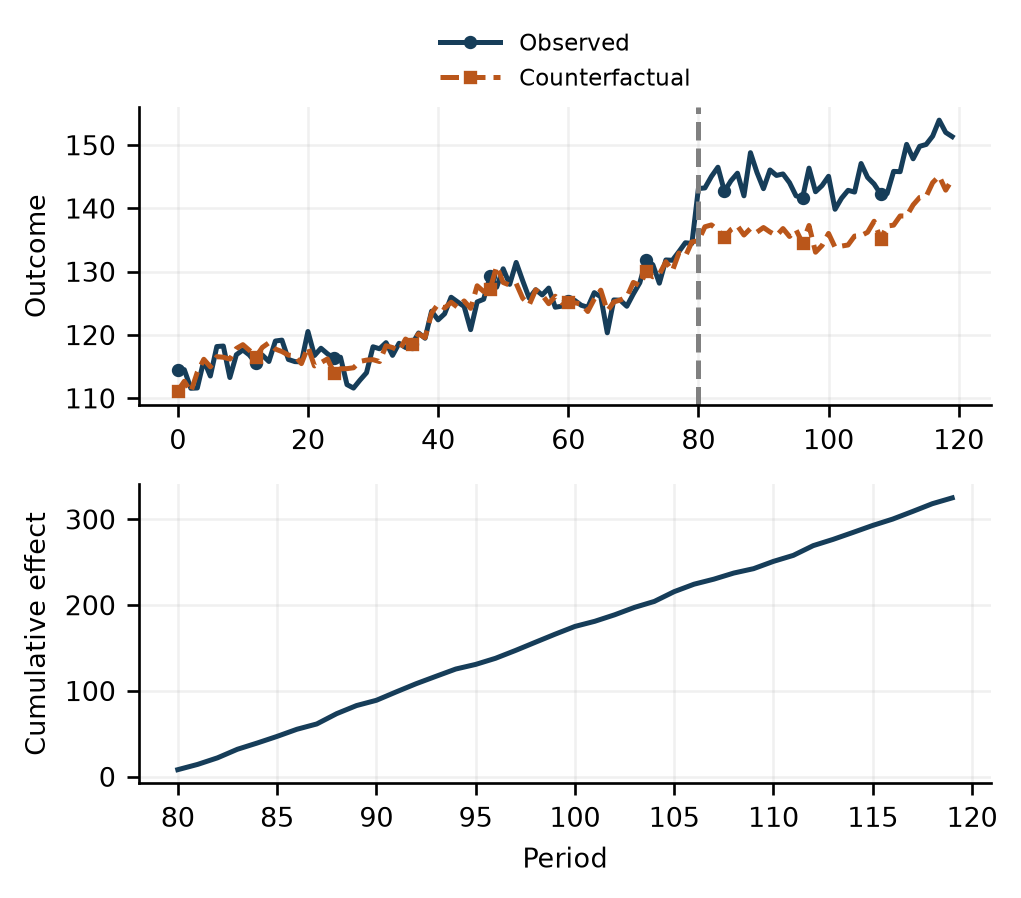

In [3]:
X=np.c_[np.ones(120),control]; beta=np.linalg.lstsq(X[:80],treated[:80],rcond=None)[0]; counter=X@beta
effect=treated[80:]-counter[80:]
did=(treated[80:].mean()-treated[:80].mean())-(control[80:].mean()-control[:80].mean())
fig,axes=plt.subplots(2,1,figsize=(4.3,3.8)); axes[0].plot(treated,label='Observed'); axes[0].plot(counter,label='Counterfactual'); axes[0].axvline(80,ls='--',color='.5'); axes[0].set_ylabel('Outcome'); axes[0].legend(fontsize=6); axes[1].plot(t[80:],np.cumsum(effect)); axes[1].set_xlabel('Period'); axes[1].set_ylabel('Cumulative effect')
save(22,2,'The counterfactual is a model assumption','Pre-period OLS relationship projected using the control series. Synthetic cumulative effects are estimates, not directly observed treatment outcomes.','## Section 4: The Full Methodology',fig)

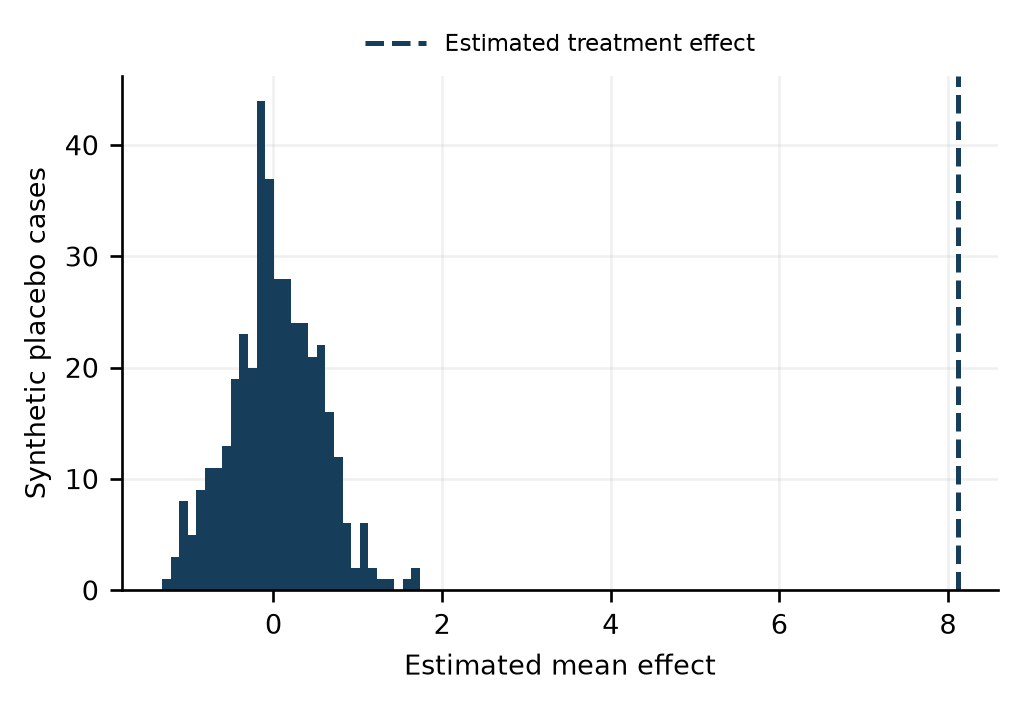

DiD: 8.302873325166019 regression effect: 8.123935558443701


In [4]:
placebos=[]
for _ in range(400):
    placebo=12+control+rng.normal(0,1.5,120)
    coeff=np.linalg.lstsq(X[:80],placebo[:80],rcond=None)[0]
    placebos.append(np.mean(placebo[80:]-X[80:]@coeff))
plt.figure(); plt.hist(placebos,bins=30); plt.axvline(effect.mean(),ls='--',label='Estimated treatment effect'); plt.xlabel('Estimated mean effect'); plt.ylabel('Synthetic placebo cases'); plt.legend(fontsize=7)
save(22,3,'A placebo tests a specific failure mechanism','Repeated no-treatment synthetic outcomes under the same generator. This simulation reference is not a randomization p-value for observational real-world data.','## Section 5: What the Counterfactual Actually Is')
print('DiD:',did,'regression effect:',effect.mean()); assert abs(effect.mean()-8)<1

## Limits and exercise
Add a treated-only pretrend or spillover into the control. Passing a pretrend test
does not prove parallel trends. IV, DML, synthetic control and causal forests require
distinct identification assumptions and are extensions rather than alternate names
for this regression.

## Failure case: perfect earlier comparability cannot rule out a later shock
Copy the SAME pre-period outcomes. Add a treated-only competitor closure after
intervention. The recorded advertising treatment remains eight units, but DiD
cannot separate it from the unrecorded six-unit shock. Pretrend checks see the
same past in both cases and cannot establish parallel untreated future trends.

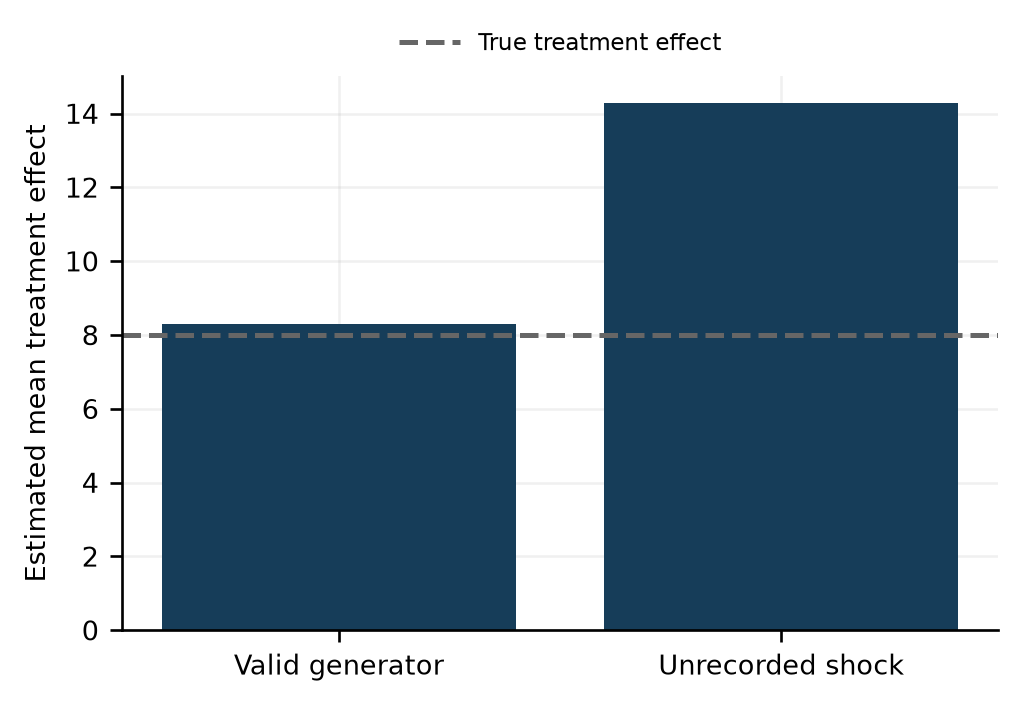

In [5]:
confounded=treated+np.where(t>=intervention,6.,0.)
bad_did=(confounded[80:].mean()-confounded[:80].mean())-(control[80:].mean()-control[:80].mean())
assert np.array_equal(confounded[:80],treated[:80])
assert np.isclose(bad_did-did,6.)
plt.figure(); plt.bar(['Valid generator','Unrecorded shock'],[did,bad_did]); plt.axhline(8,color='.4',ls='--',label='True treatment effect')
plt.ylabel('Estimated mean treatment effect'); plt.legend(fontsize=7)
save(22,4,'The same pretrends can support different explanations','Both synthetic cases have identical pre-period data. A six-unit treated-only post-period shock contaminates DiD without changing the true eight-unit intervention effect.','## Section 5: What the Counterfactual Actually Is')

## Identification worksheet: choose evidence before choosing a model
Record treatment, population, timing, comparator, outcome and effect horizon.
- Adjustment: defend measured pre-treatment common causes and overlap. Do not
  control indiscriminately for mediators or colliders.
- Difference-in-differences: defend untreated parallel trends, no anticipation,
  and no relevant spillovers or treated-only co-interventions.
- Cutoff design: defend continuity, no sorting/manipulation and no other rule
  changing at the cutoff; the effect is local, not automatically market-wide.
- Instrument/natural variation: defend assignment, relevance and exclusion of
  other outcome pathways; additional assumptions determine the effect identified.
These designs are discussed here, not implemented under alternate names for OLS.
Prefer an ethical, feasible and sufficiently informative experiment when a material
action depends on an effect these comparisons cannot identify. An underpowered or
contaminated experiment is not a cure. If neither design is credible, report a
bounded scenario and the missing evidence; do not certify causality from fit.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
A regular series with the treated outcome and at least one control series; name every control column in config `controls`; without that key the tool looks for one column literally named `control`. Synthetic control and placebo-in-space need at least two, better three or more, controls. Declare `intervention` (the first treated timestamp) and write down the `identification` argument before running.

Minimal **format illustration**, not sufficient training data:

```csv
timestamp,control,control_2,control_3,treated
2010-01-01,99.9,80.7,49.1,104.3
2010-02-01,100.3,81.0,52.4,105.1
2010-03-01,100.1,80.9,47.8,104.6
```

## Explain the mechanism

A counterfactual is the outcome that would have occurred without treatment. It is unobserved for treated units, so an effect estimate depends on a comparison argument. More sophisticated prediction cannot by itself supply missing identification.

## Work through the arithmetic

Treated rises from 100 to 120; control rises from 80 to 90. DiD is (120-100)-(90-80)=10. If an unrelated treated-only event contributed 6, the same observed DiD would combine treatment 4 and shock 6. The pre-period data cannot distinguish those explanations.

## Adapt the lesson to reader data

Replace treated/control/time arrays and intervention boundary with aligned observed outcomes. Keep candidate-control and pre-period selection separate from post-effect estimation. Do not label the regression block CausalImpact or BSTS; it is a pre-period OLS counterfactual.

For this chapter, settle these questions before fitting: What treatment, alternative and population define the effect? When did treatment start? Why did it vary? Could controls be affected? What else changed at the same time?

## Interpret the actual lesson outputs

The controlled lesson has an eight-unit treatment effect. Adding a six-unit treated-only post shock preserves identical prehistory while increasing DiD by six. The placebo simulation describes a known generator; it is not a randomization p-value for an arbitrary observational dataset.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `timestamp,observed,ols_counterfactual,ols_effect,post,relative_period,sc_counterfactual,sc_effect`.
- `summary.json`: `did,post_mean_effect,pre_rmse,sc_weights,sc_post_mean_effect,sc_pre_rmse,placebo_space,placebo_time,event_study,pretrend,identification,controls` plus method, interpretation, assumptions, not_done and status.

The tool computes difference-in-differences, a pre-period OLS counterfactual on all declared controls, and, with two or more controls, a synthetic control with nonnegative weights summing to one fitted on the pre-period only. It then runs placebo-in-space (each control treated in turn against the remaining donors; the p-value is the treated unit's rank on post-effect over pre-RMSE), placebo-in-time (`placebos` pseudo interventions inside the pre period; p is the share at least as large as the estimate), and an event-study table of per-period effects over `event_window` pre periods and all post periods with a pre-trend slope test. Every estimate is conditional on the declared identification; the tool does not decide whether the comparison is defensible. The tool runs only when asked; the assistant decides, with the reader, whether the method fits before running it.

## Decide what the evidence supports

Estimation necessarily uses post outcomes; model/design selection must not chase the effect. Serial and group dependence require suitable inference, not naive independent row standard errors. Pretrend tests cannot rule out future differential shocks.

With no credible unaffected comparator or assignment argument, report observed changes and bounded scenarios rather than causal lift. If prehistory is short, disclose weak trend diagnostics. An experiment is useful only if ethical, feasible, adequately powered and uncontaminated.

The applied deliverable must make these items inspectable: `results.csv` columns: `timestamp,observed,ols_counterfactual,ols_effect,post,relative_period,sc_counterfactual,sc_effect`; `summary.json` keys: `did,post_mean_effect,pre_rmse,sc_weights,sc_post_mean_effect,sc_pre_rmse,placebo_space,placebo_time,event_study,pretrend,identification,controls` plus method, interpretation, assumptions, not_done and status. Quote the placebo p-values and the pre-trend flag with the effect; an effect without them is a difference, not evidence.

## Three exercises with worked solutions

### Exercise 1

Treated change 30, control change 12: DiD?

**Worked solution.** 18 outcome units under the design assumptions.

### Exercise 2

The control receives spillover advertising after launch. Is its post outcome a clean untreated comparator?

**Worked solution.** No. Spillover contaminates the counterfactual; use another defended design or report the limitation.

### Exercise 3

Pretrend p-value is .7. Does this prove parallel untreated future trends?

**Worked solution.** No. Nonsignificance does not establish the identifying assumption or rule out later shocks.

## Business-reader application

Use this request with the skill:

> Apply chapter 22 to intervention.csv, state the identifying assumptions before computing effects, and show how a plausible concurrent shock changes the interpretation.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [6]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch22.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch22.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(22, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch22-workshop-results.csv', index=False)
_ = (workshop_output/'ch22-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: DiD, OLS counterfactual, synthetic control, placebo and event-study checks
Status: passed

Interpretation: DiD 9.906; OLS counterfactual post-mean effect 7.873 (pre RMSE 0.9757); synthetic control effect 9.435 with weights {'control': 0.999999992719875, 'control_2': 0.0, 'control_3': 7.280124898219316e-09}; placebo-in-space p 0.25; placebo-in-time p 0.00. Pre-trend slope p 0.96. Identification: Synthetic controlled generator; treated-only shock absent by construction. These are conditional counterfactual calculations, not automatic causal identification.

Assumptions:
  - Controls unaffected by the intervention
  - Pre-period relationship would have continued untreated
  - No concurrent treated-only shocks
  - Intervention date declared before estimation

Evidence:
  did: 9.906
  post_mean_effect: 7.873
  pre_rmse: 0.9757
  sc_weights: control=1, control_2=0, control_3=7.28e-09
  sc_post_mean_effect: 9.435
  sc_pre_rmse: 3.3
  placebo_space: <4 entries>
  placebo_time: <3 entri